# Assignment 1: Wrangling and EDA
### Foundations of Machine Learning

**Q1.** This question provides some practice cleaning variables which have common problems.
1. Numeric variable: For `airbnb_NYC.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. Categorical variable: For the Minnesota police use of for data, `mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing? For the remaining missing values, replace the `np.nan/None` values with the label `Missing`.
3. Dummy variable: For `metabric.csv`, convert the `Overall Survival Status` variable into a dummy/binary variable, taking the value 0 if the patient is deceased and 1 if they are living.
4. Missing values: For `airbnb_NYC.csv`, determine how many missing values of `Review Scores Rating` there are. Create a new variable, in which you impute the median score for non-missing observations to the missing ones. Why might this bias or otherwise negatively impact your results?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import urllib.request
import os
import zipfile
import os
def download_data(force=False):
    """Download and extract course data from Zenodo."""
    
    zip_path = 'data.zip'
    data_dir = './data'
    
    if not os.path.exists(zip_path) or force:
        print("Downloading course data...")
        urllib.request.urlretrieve(
            'https://zenodo.org/records/18235955/files/data.zip?download=1',
            zip_path
        )
        print("Download complete")
    
    if not os.path.exists(data_dir) or force:
        print("Extracting data files...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)

        print("Data extracted")
    
    return data_dir



if __name__ == "__main__":
    download_data()

Download complete
Extracting data files...
Data extracted


In [ ]:
#1

df = pd.read_csv('./data/airbnb_NYC.csv', encoding = 'latin1')
df.head()

#number of missing values:
missing_price = df['Price'].isna().sum()
print(missing_price)

#cleaning
df['clean_prices'] = df['Price'].str.replace(",", "")
df['clean_prices'] = pd.to_numeric(df['clean_prices'], errors='coerce')
print(df['clean_prices'].describe)




0
<bound method NDFrame.describe of 0        145
1         37
2         28
3        199
4        549
        ... 
30473    300
30474    125
30475     80
30476     35
30477     80
Name: clean_prices, Length: 30478, dtype: int64>


**Q1.1 Choice Explanation:**

When I checked to see the number of missing values, there were none for prices, thus, I can go ahead and clean the data without worrying about null values. Because the data type for Price is a string, due to the comma separator pattern, we have to first remove the commas. I did so by using the pattern string replacer technique. From there, I turned the string into numeric using the pandas built-in data type converter. 



In [ ]:
#1.2
df = pd.read_csv('./data/mn_police_use_of_force.csv')

#number of missing subejct injury
num_of_missing_subject_injury = df['subject_injury'].isna().sum()
proportion = num_of_missing_subject_injury * 100 / len(df['subject_injury']) 

print(f'Proportion that are missing: {proportion:.1f}%')

#mapped missing values to 'Missing'
df['subject_injury'] = df['subject_injury'].fillna('Missing')
df.head()

pd.crosstab(df['subject_injury'], df['force_type'])


count     3077
unique       2
top        Yes
freq      1631
Name: subject_injury, dtype: object
Proportion that are missing: 76.2%


force_type,Baton,Bodily Force,Chemical Irritant,Firearm,Gun Point Display,Improvised Weapon,Less Lethal,Less Lethal Projectile,Maximal Restraint Technique,Police K9 Bite,Taser
subject_injury,,,,,,,,,,,
Missing,2,7051,1421,0,27,74,87,0,170,31,985
No,0,1093,131,2,33,34,0,1,0,2,150
Yes,2,1286,41,0,44,40,0,2,0,44,172


**Q1.2 Answers:**

76.2% of the subject injury column is empty. Based on the cross tabulation of subject injury to force type, it seems that a good portion of subject injury is missing for almost all force types, which could mean that the police department is purposely leaving it out because it makes them look bad.

In [ ]:
#1.3
df = pd.read_csv('./data/metabric.csv')

dict = {'0:LIVING':1, '1:DECEASED': 0}

df['Overall Survival Status (Binary)'] = df['Overall Survival Status'].map(dict)
df.head()

,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Chemotherapy,Hormone Therapy,Lymph nodes examined positive,Mutation Count,Nottingham prognostic index,Overall Survival (Months),Overall Survival Status,Radio Therapy,TMB (nonsynonymous),Tumor Size,Tumor Stage,Overall Survival Status (Binary)
0,43.19,BREAST CONSERVING,Breast Cancer,NO,YES,0.0,2.0,4.020,84.633333,0:LIVING,YES,2.615035,10.0,1.0,1
1,48.87,MASTECTOMY,Breast Cancer,YES,YES,1.0,2.0,4.030,163.700000,1:DECEASED,NO,2.615035,15.0,2.0,0
2,47.68,MASTECTOMY,Breast Cancer,YES,YES,3.0,1.0,4.050,164.933333,0:LIVING,YES,1.307518,25.0,2.0,1
3,76.97,MASTECTOMY,Breast Cancer,YES,YES,8.0,2.0,6.080,41.366667,1:DECEASED,YES,2.615035,40.0,2.0,0
4,78.77,MASTECTOMY,Breast Cancer,NO,YES,0.0,4.0,4.062,7.800000,1:DECEASED,YES,5.230071,31.0,4.0,0


In [47]:
#1.4
df = pd.read_csv('./data/airbnb_NYC.csv', encoding = 'latin1')
df.head()

num_of_missing_review_score_rating = df['Review Scores Rating'].isna().sum()
print(num_of_missing_review_score_rating)
print(num_of_missing_review_score_rating / len(df))


df['Review Scores Rating (Cleaned)'] = df['Review Scores Rating'].fillna(df['Review Scores Rating'].median())
df.head()


8323
0.27308222324299497


,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating,Review Scores Rating (Cleaned)
0,5162530,NaN,1 Bedroom in Prime Williamsburg,Brooklyn,Apartment,NaN,Entire home/apt,11249.0,1.0,1,0,145,NaN,94.0
1,33134899,NaN,"Sunny, Private room in Bushwick",Brooklyn,Apartment,NaN,Private room,11206.0,1.0,1,1,37,NaN,94.0
2,39608626,NaN,Sunny Room in Harlem,Manhattan,Apartment,NaN,Private room,10032.0,1.0,1,1,28,NaN,94.0
3,500,6/26/2008,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199,NaN,94.0
4,500,6/26/2008,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0,96.0


**Q1.4 Answer:**

Using the median as the replacement for missing values may skew the rating to be more in the middle which in reality is not the case. If someone were to be using the dataset to find out if a certain property has good rating and then sees it rated highly, this would be giving them possibly untrue information because the rating is based on the median of the available data which is pretty high. 

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks.

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work. What does work?
2. Drop any columns that do not contain data.
3. What is an observation? Carefully justify your answer, and explain how it affects your choices in cleaning and analyzing the data.
4. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
5. Clean the Age variable and make a histogram of the ages of the victims.
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?
7. Clean the `Fatal Y/N` variable so it only takes three values: Y, N, and Unknown.
8. Is the attack more or less likely to be fatal when the attack is provoked or unprovoked? Thoughts?

In [131]:
#2.1
shark = pd.read_excel('./data/GSAF5.xls')
shark.head()

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,20th January,2026.0,Unprovoked,Australia,NSW,Point Plomber North of Port Macquarie,Surfing,Paul Zvirdinas,M,39,...,Bull shark,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,19th January,2026.0,Unprovoked,Australia,NSW,Dee Why,Surfing,Unknown,M,11,...,Bull shark,Andy Currie,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,19th January,2026.0,Unprovoked,Australia,NSW,North Steyne,Surfing,Andre de Ruyter,M,27,...,5m shark species not determined,9 News: Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,18th January,2026.0,Unprovoked,Australia,NSW,Nielsen Park Vaucluse Sydney Harbour,Jumping off rocks,Nico Antic,M,12,...,Bull shark,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10th January,2026.0,Unprovoked,Australia,NSW,Avalon Beach,Surfing,Paul Stanton,M,?,...,Unknown,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [132]:
#2.2
shark2 = shark.drop(columns=['pdf', 'href formula', 'href', 'Case Number', 'Case Number.1', 'original order', 'Unnamed: 21', 'Unnamed: 22'])
shark2['Type'].value_counts()

Type
Unprovoked             5221
Provoked                642
Invalid                 552
Watercraft              355
Sea Disaster            242
Questionable             26
Boat                      7
 Provoked                 2
unprovoked                1
?                         1
Unconfirmed               1
Unverified                1
Under investigation       1
Name: count, dtype: int64

**2.3:**

An observation that I can make from looking at the dataset is that type of shark attack has some redundant values such as unprovoked when there is already an Unprovoked category. Some other questionable categories are Unverified, Unconfirmed, Questionable, etc. As a result, I would clean the data by first decreasing the amount of attack type categories and remove instances that are of other types because they would cause more confusion and noise to the analysis.

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Year', ylabel='Count'>

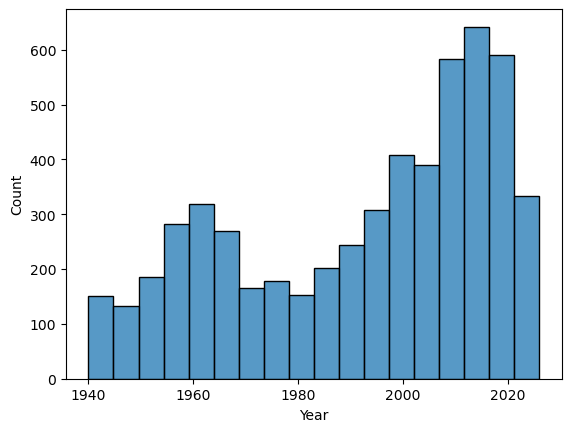

In [133]:
#2.4
shark2 = shark2.loc[(shark2['Year'] >= 1940) & (shark2['Year'].notna()), :]

sns.histplot(data=shark2, x=shark2['Year'])

**2.4:**

Over time, the shark attacks increase, but there has been a drop in attacks after 2020.

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Age', ylabel='Count'>

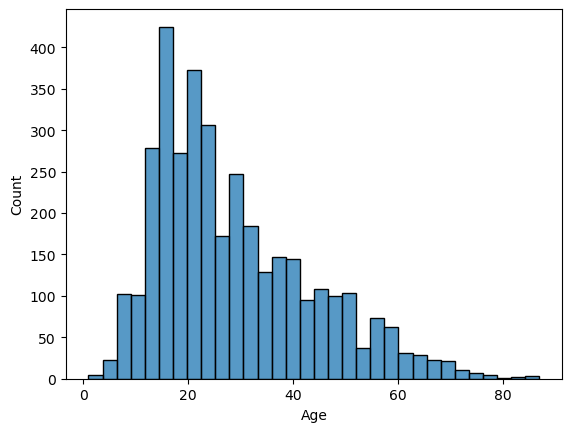

In [134]:
#2.5
shark2['Age'] = pd.to_numeric(shark2['Age'], errors='coerce')
shark2 = shark2.loc[(shark2['Age'].notna()),:]

sns.histplot(data=shark2, x=shark2['Age'])

In [136]:
#2.6
shark2 = shark2.loc[(shark2['Type'] == 'Provoked') | (shark2['Type'] == 'Unprovoked') | (shark2['Type'] == 'Unknown'), :]
prop_of_unprovoked = len(shark2.loc[(shark2['Type'] == 'Unprovoked')]) * 100 / len(shark2)
print(f'Proportion of unprovoked shark attacks: {prop_of_unprovoked:0.1f}%')

Proportion of unprovoked shark attacks: 91.1%


In [150]:
#2.7
shark2 = shark2.loc[(shark2['Fatal Y/N'] == 'Y') | (shark2['Fatal Y/N'] == 'N') | (shark2['Fatal Y/N'] == 'Unknown'), :]
shark2['Fatal Y/N'].value_counts()

print(pd.crosstab(shark2['Type'], shark2['Fatal Y/N']))

Fatal Y/N      N    Y
Type                 
Provoked     282    8
Unprovoked  2494  494


**Q2.8:**

Both fatal and nonfatal attacks are mostly unprovoked, which might mean that whether the shark was provoked does not dictate whether the attack will be fatal.

**Q3.** Open the "tidy_data.pdf" document available in `https://github.com/ds4e/wrangling`, which is a paper called *Tidy Data* by Hadley Wickham.

  1. Read the abstract. What is this paper about?
  2. Read the introduction. What is the "tidy data standard" intended to accomplish?
  3. Read the intro to section 2. What does this sentence mean: "Like families, tidy datasets are all alike but every messy dataset is messy in its own way." What does this sentence mean: "For a given dataset, it’s usually easy to figure out what are observations and what are variables, but it is surprisingly difficult to precisely define variables and observations in general."
  4. Read Section 2.2. How does Wickham define values, variables, and observations?
  5. How is "Tidy Data" defined in section 2.3?
  6. Read the intro to Section 3 and Section 3.1. What are the 5 most common problems with messy datasets? Why are the data in Table 4 messy? What is "melting" a dataset?
  7. Why, specifically, is table 11 messy but table 12 tidy and "molten"?

**Q3.1:**

After reading the abstract, it seems that this paper is about how to go about tidying datasets, providing a framwork that we can follow to tidy up un-tidy datasets.

**Q3.2**

The tidy data standard intends to provide a framework that people can use to simplify the development of data analysis and make sense of messy datasets.

**Q3.3**

- First sentence: every dataset follow similar physical structure, but what makes the individual datasets messy lies within their semantics. 
- Second sentence: it is easy to differentiate between an observation and a variable, when it comes to finding out the purpose or the functionality that connects the variables and/or observations, we have to rely more on the envoirnment or the goal of the dataset. What are we trying to show or find with the dataset will dictate what they may represent. 

**Q3.4**

- Values: numbers or strings
- Variables: conatins all values that measure the same underlying attribute across units
- Observations: contains all values measured on the same unit acriss attributes

**Q3.5**

Tidy Data: a standard way of mapping the meaning of a dataset to its structure. Variable is a column, observation is a row, and each type of observational unit forms a table.

**Q3.6**

1. Column headers are values, not variable names
2. Multiple variables are stored in one column
3. Variables are stored in both rows and columns
4. Multiple types of observational units are stored in the same table
5. A single observational unit is stored in multiple tables

Table 4 is messy because the column headers are values instead of variables names, and the variables forms both the rows and the columns. 

Melting a dataset is when you turn the columns into rows. Melting is parameterised by a list of columns that are already variables.

**Q3.7**

In table 11, the element column is not a variable, it stores the names of the variables. It has variables in individual columns, spread acorss columns, and across rows. Months with less than 31 days have structural missing values for the last days of the month. 

Table 12 is a molten, tidy dataset because the missing values have been dropped, and they melted it with its colvars and the column that contains variable names, element. Then it was further tidied by rotating the element variable back out into the columns. In this way, there is one variable in each column and each row represents a days' observation.




**Q4.** This question looks at financial transfers from international actors to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? 

For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
5. What are the top 15 institutions in terms of the total amount of money they receive? Make a histogram of the total amount received by all institutions. 
6. Which giftors provide the most money, in total? 

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Axes(0.125,0.11;0.775x0.77)
Findings: 
I think it is interesting there there are foreign gift 
amounts in the negatives, additionally, the range is really large
 among the gift amounts, from the negatives to 100,000,000.


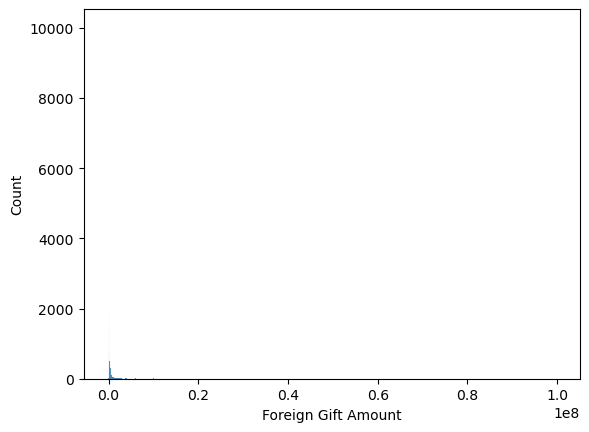

In [ ]:
#4.1
foreign = pd.read_csv('./data/ForeignGifts_edu.csv')

#4.2
print(sns.histplot(foreign['Foreign Gift Amount']))
foreign['Foreign Gift Amount'].describe()
print("Findings: \n" \
"I think it is interesting there there are foreign gift " \
"\namounts in the negatives, additionally, the range is really large" \
"\namong the gift amounts, from the negatives to 100,000,000.")

Axes(0.125,0.11;0.775x0.77)
Monetary Gift Proportion: 38.75%
Contract Gift Type Proportion: 61.21%
Real Estate Proportion: 0.04%


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


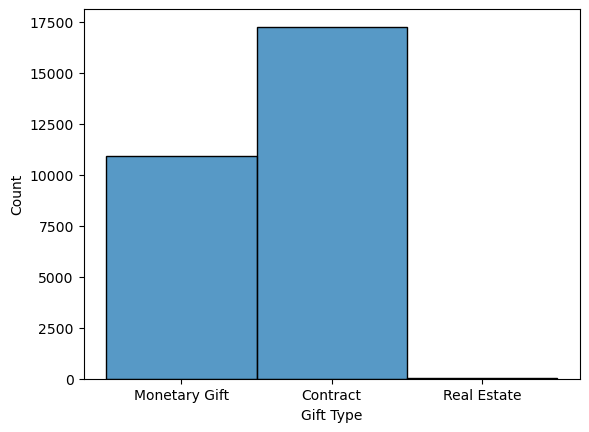

In [165]:
#4.3
print(sns.histplot(foreign['Gift Type']))

num_monetary = (foreign['Gift Type'] == 'Monetary Gift').sum() / len(foreign['Gift Type'])
num_contract = (foreign['Gift Type'] == 'Contract').sum() / len(foreign['Gift Type'])
num_real_estate = (foreign['Gift Type'] == 'Real Estate').sum() / len(foreign['Gift Type'])

print(f'Monetary Gift Proportion: {num_monetary*100:0.2f}%')
print(f'Contract Gift Type Proportion: {num_contract*100:0.2f}%')
print(f'Real Estate Proportion: {num_real_estate*100:0.2f}%')


In [ ]:
#4.4

top_15_number_of_gifts = foreign['Gift Type'].groupby(foreign['Country of Giftor']).count()
print(top_15_number_of_gifts.sort_values(ascending=False).head(15))

top_15_amount_in_gifts = foreign['Foreign Gift Amount'].groupby(foreign['Country of Giftor']).sum()
print(top_15_amount_in_gifts.sort_values(ascending=False).head(15))

Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: Gift Type, dtype: int64
Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
AUSTRALIA                248409202
Name: Foreign Gift Amount, dtype: int64


Institution Name
Carnegie Mellon University                       1477922504
Cornell University                               1289937761
Harvard University                                954803610
Massachusetts Institute of Technology             859071692
Yale University                                   613441311
Texas A&M University                              521455050
Johns Hopkins University                          502409595
Northwestern University                           402316221
Georgetown University                             379950511
University of Chicago (The)                       364544338
University of Colorado Boulder                    360173159
Duke University                                   343699498
Brigham Young University                          323509863
Stanford University                               319561362
University of Texas MD Anderson Cancer Center     301527419
Name: Foreign Gift Amount, dtype: int64


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Foreign Gift Amount', ylabel='Count'>

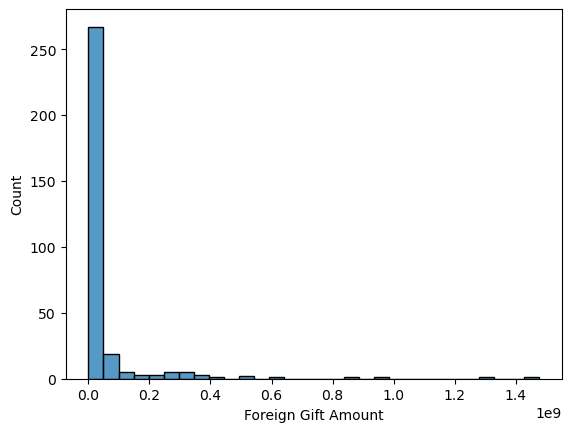

In [190]:
#4.5
top_15_recieved = foreign['Foreign Gift Amount'].groupby(foreign['Institution Name']).sum()
print(top_15_recieved.sort_values(ascending=False).head(15))

sns.histplot(top_15_recieved, bins=30)

In [192]:
top_giftors = foreign['Foreign Gift Amount'].groupby(foreign['Giftor Name']).sum()
print(top_giftors.sort_values(ascending=False).head(10))

Giftor Name
Qatar Foundation                       1166503744
Qatar Foundation/Qatar National Res     796197000
Qatar Foundation for Education          373945215
Anonymous                               338793629
Saudi Arabian Cultural Mission          275221475
HCL                                     190000000
Church of Jesus Christ of LDS           185203715
Emirates Institute for Advanced Sc      170641244
QIC                                     148355497
Anonymous #9                             96334996
Name: Foreign Gift Amount, dtype: int64


**Q5.** This question provides some practice doing exploratory data analysis and visualization.

We'll use the `college_completion.csv` dataset from the US Department of Education. The "relevant" variables for this question are:
  - `level` - Level of institution (4-year, 2-year)
  - `aid_value` - The average amount of student aid going to undergraduate recipients
  - `control` - Public, Private not-for-profit, Private for-profit
  - `grad_100_value` - percentage of first-time, full-time, degree-seeking undergraduates who complete a degree or certificate program within 100 percent of expected time (bachelor's-seeking group at 4-year institutions)

1. Load the `college_completion.csv` data with Pandas.
2. How many observations and variables are in the data? Use `.head()` to examine the first few rows of data.
3. Cross tabulate `control` and `level`. Describe the patterns you see in words.
4. For `grad_100_value`, create a kernel density plot and describe table. Now condition on `control`, and produce a kernel density plot and describe tables for each type of institutional control. Which type of institution appear to have the most favorable graduation rates?
5. Make a scatterplot of `grad_100_value` by `aid_value`, and compute the covariance and correlation between the two variables. Describe what you see. Now make the same plot and statistics, but conditioning on `control`. Describe what you see. For which kinds of institutions does aid seem to vary positively with graduation rates?

In [ ]:
#5.1
college = pd.read_csv('./data/college_completion.csv')

#5.2
print("Observations:",college.shape[0], "Variables:", college.shape[1])
college.head()

#5.3
pd.crosstab(college['control'], college['level'])

Observations: 3798 Variables: 63


level,2-year,4-year
control,,
Private for-profit,465,527
Private not-for-profit,68,1180
Public,926,632


**Q5.3**

The most observations seem to be 4-year, private not-for-profit, while the least is 2-year private not-for-profit. Private controls seem to have a trend of increasing observations when moving up in level, but the opposite is true for public control. 

Axes(0.125,0.11;0.775x0.77)
It seems that the grad 100 value has the highest density at around 10
and then it continues to decline as it increases.


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


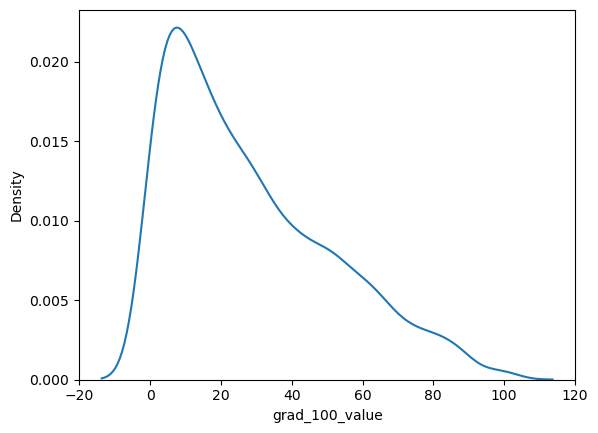

In [211]:
#5.4

print(sns.kdeplot(college['grad_100_value']))

print('It seems that the grad 100 value has the highest density at around 10\n' \
'and then it continues to decline as it increases.')


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='grad_100_value', ylabel='Density'>

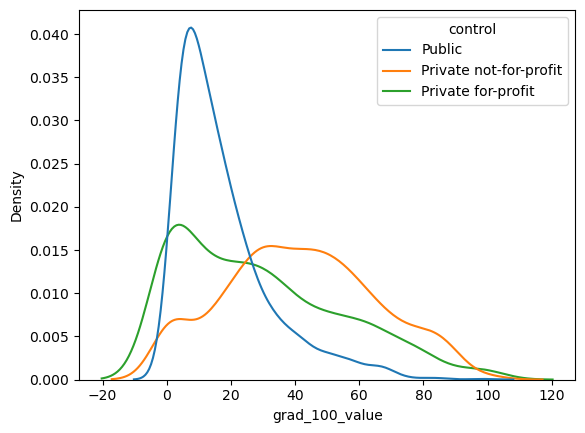

In [ ]:
#5.4
sns.kdeplot(data=college, x='grad_100_value', hue='control', common_norm=False)


**Q5.4**

For public institutions, it seems that most of them have around 0-20% graduation rate and the density declines as we move up on the graduation rate. For private not-for-profit institutions, there seem to be more of a peak at around 40% graduation value, which then the decrease is much shallower as we increase in the x-value. For private for-profit facilities, the peak density is at a lower graduation value than the others, and declines over the increase in graduation value.

It seems to be that the private not-for-profit have the most favorable graduation rates as its peak density is at the graduation value that is higher than the other two types of facilities. 

Covariance: 
                 grad_100_value     aid_value
grad_100_value      543.483382  8.861048e+04
aid_value         88610.483169  4.121201e+07
Correlation: 
                 grad_100_value  aid_value
grad_100_value        1.000000   0.575879
aid_value             0.575879   1.000000


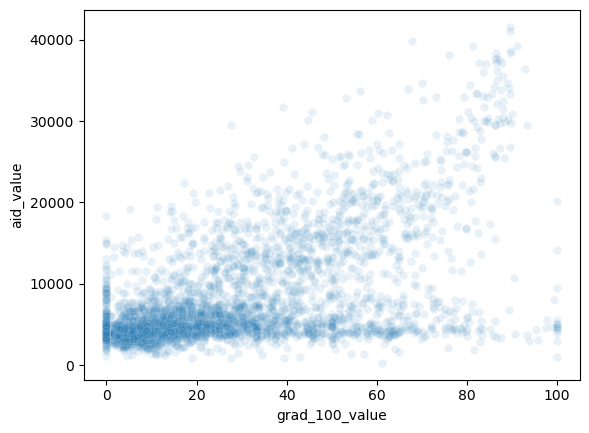

In [224]:
#5.5

sns.scatterplot(x=college['grad_100_value'], y=college['aid_value'], alpha=0.1)
covariance = college.loc[:,['grad_100_value','aid_value']].cov(numeric_only=True)
correlation = college.loc[:,['grad_100_value','aid_value']].corr(numeric_only=True)

print('Covariance: \n', covariance)
print('Correlation: \n',correlation)


**Q5.5**

Most of the datapoints are at the lower left corner of the plot, but there is a faint trend of some data points moving up in graduation value as the aid value increases.

Covariance conditioned on control: 
                                        grad_100_value     aid_value
control                                                            
Private for-profit     grad_100_value      655.446387  6.897525e+03
                       aid_value          6897.524957  1.957540e+06
Private not-for-profit grad_100_value      554.660462  1.092741e+05
                       aid_value        109274.123337  6.041488e+07
Public                 grad_100_value      216.956489  1.535515e+04
                       aid_value         15355.146212  4.564360e+06
Correlation conditioned on control: 
                                        grad_100_value  aid_value
control                                                         
Private for-profit     grad_100_value        1.000000   0.188363
                       aid_value             0.188363   1.000000
Private not-for-profit grad_100_value        1.000000   0.601591
                       aid_value             0.601591   

<Axes: xlabel='grad_100_value', ylabel='aid_value'>

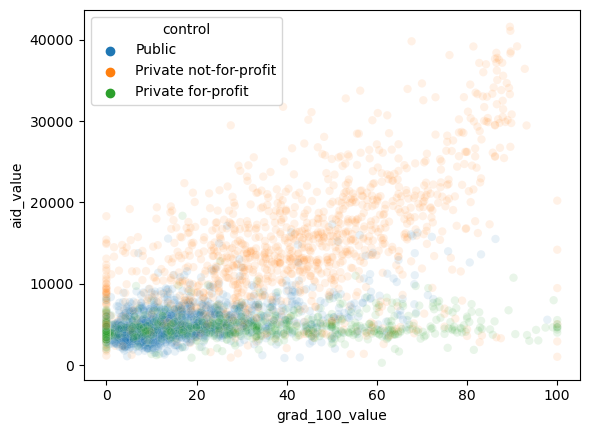

In [223]:
#5.5

covariance_by_control = college.groupby('control')[['grad_100_value', 'aid_value']].cov()
correlation_by_control = college.groupby('control')[['grad_100_value', 'aid_value']].corr()

print('Covariance conditioned on control: \n', covariance_by_control)
print('Correlation conditioned on control: \n',correlation_by_control)

sns.scatterplot(x=college['grad_100_value'], y=college['aid_value'], hue=college['control'], alpha=0.1)

**Q5.5**

Looking at the plot, it seems like there is a great concentration at the lower left part of it, which is low aid value and low graduation value. As it moves outward and up, I mostly just see the private not-for-profit datapoints moving up in both aid value and graduation value. The public datapoints seem to mostly stick to the left end of the plot, while the green does move toward the higher graduation rates more, but still stay low in aid value. 

It seem that private not-for-profit institutions vary positively with graduation rates as shown by both the plot and the higher correlation value. 

**Q6.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

We're going to look at **linear transformations** of $X$, $Y = a + bX$. So we take each value of $X$, $x_i$, and transform it as $y_i = a + b x_i$. 

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $ \text{cov}(X,X) = s^2$.
3. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
4. Show that $\text{cov}(a+bX,a+bY) = b^2 \text{cov}(X,Y) $. Notice, this also means that $\text{cov}(bX, bX) = b^2 s^2$.
5. Suppose $b>0$ and let the median of $X$ be $\text{med}(X)$. Is it true that the median of $a+bX$ is equal to $a + b \times \text{med}(X)$? Is the IQR of $a + bX$ equal to $a + b \times \text{IQR}(X)$?
6. Show by example that the means of $X^2$ and $\sqrt{X}$ are generally not $(m(X))^2$ and $\sqrt{m(X)}$. So, the results we derived above really depend on the linearity of the transformation $Y = a + bX$, and transformations like $Y = X^2$ or $Y = \sqrt{X}$ will not behave in a similar way.

**Q6 Reponse:**

![homework 1, question 6 answers](images/hw1_q6.png)


**Q7.** This question provides some practice doing exploratory data analysis and visualization.

We'll use the `ames_prices.csv` dataset. The "relevant" variables for this question are:
  - `price` - Sale price value of the house
  - `Bldg.Type` - Building type of the house (single family home, end-of-unit townhome, duplex, interior townhome, two-family conversion)

1. Load the `college_completion.csv` data with Pandas.
2. Make a kernel density plot of price and compute a describe table. Now, make a kernel density plot of price conditional on building type, and use `.groupby()` to make a describe type for each type of building. Which building types are the most expensive, on average? Which have the highest variance in transaction prices?
3. Make an ECDF plot of price, and compute the sample minimum, .25 quantile, median, .75 quantile, and sample maximum (i.e. a 5-number summary).
4. Make a boxplot of price. Are there outliers? Make a boxplot of price conditional on building type. What patterns do you see?
5. Make a dummy variable indicating that an observation is an outlier.
6. Winsorize the price variable, and compute a new kernel density plot and describe table. How do the results change?

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: price, dtype: float64
            count           mean           std      min       25%       50%  \
Bldg.Type                                                                     
1Fam       2425.0  184812.041237  82821.802329  12789.0  130000.0  165000.0   
2fmCon       62.0  125581.709677  31089.239840  55000.0  106562.5  122250.0   
Duplex      109.0  139808.935780  39498.973534  61500.0  118858.0  136905.0   
Twnhs       101.0  135934.059406  41938.931130  73000.0  100500.0  130000.0   
TwnhsE      233.0  192311.914163  66191.738021  71000.0  145000.0  180000.0   

                75%       max  
Bldg.Type                      
1Fam       220000.0  755000.0  
2fmCon     140000.0  228950.0  
Duplex     153337.0  269500.0  
Twnhs      170000.0  280750.0  
TwnhsE     222000.0  392500.0  


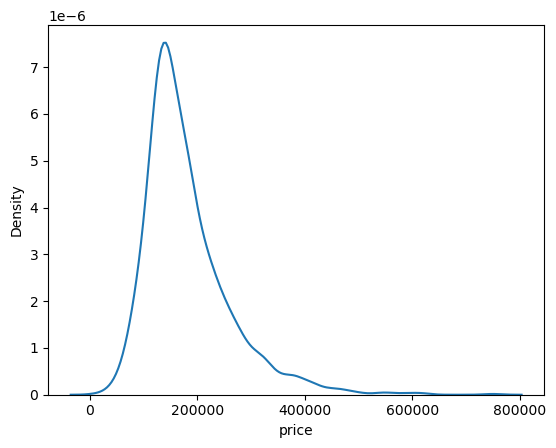

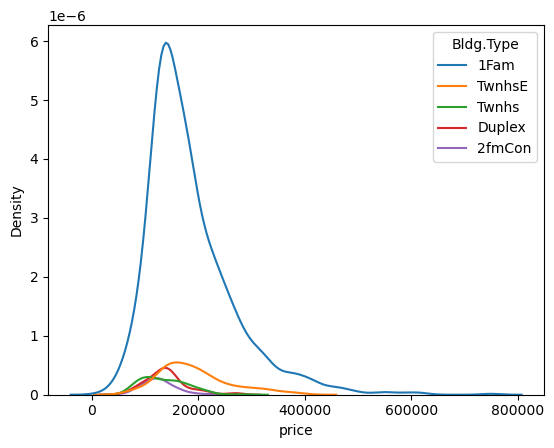

In [230]:
#7.1
ames = pd.read_csv('./data/ames_prices.csv')

#7.2
sns.kdeplot(ames['price'])
print(ames['price'].describe())
plt.figure()
sns.kdeplot(data=ames, x=ames['price'], hue=ames['Bldg.Type'])
print(ames['price'].groupby(ames['Bldg.Type']).describe())

**Q7.2**

On average, the most expensive building type is Townhouse End Unit (TwnhsE). The highest variance in prices is Single-family detached (1Fam).

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: price, dtype: float64

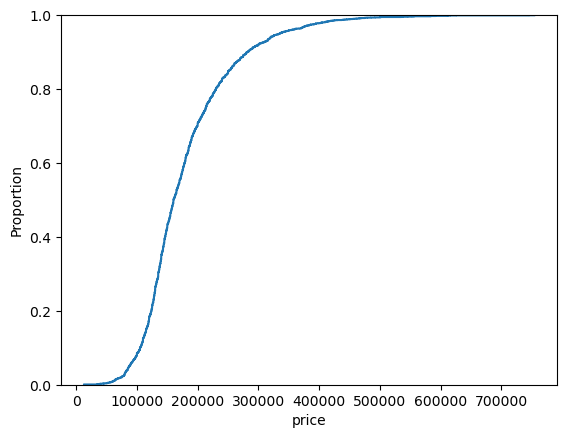

In [232]:
#7.3

sns.ecdfplot(ames['price'])
ames['price'].describe()

There are 137 outliers
All Outliers are greater than the upper whisker
Most prices fall within 0 to 350,000 range
The interquartile is much narrow in comparsion to the outer quartiles, which may mean higher variance


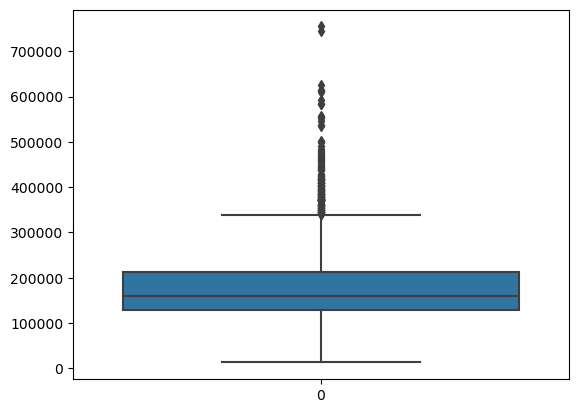

In [242]:
#7.4

sns.boxplot(ames['price'])
q75 = np.nanquantile(ames['price'], .75)
q25 = np.nanquantile(ames['price'], .25)
iqr = q75 - q25
upper_whisker = q75 + 1.5 * iqr
lower_whisker = q25 - 1.5 * iqr

outliers = ((ames['price'] < lower_whisker) | (ames['price'] > upper_whisker)).sum()
print("There are", outliers, "outliers")
print("All Outliers are greater than the upper whisker")
print("Most prices fall within 0 to 350,000 range")
print("The interquartile is much narrow in comparsion to the outer quartiles, which may mean higher variance")

In [ ]:
#7.5

ames[outliers] = ((ames['price'] < lower_whisker) | (ames['price'] > upper_whisker))
ames[outliers]

0       False
1       False
2       False
3       False
4       False
        ...  
2925    False
2926    False
2927    False
2928    False
2929    False
Name: 137, Length: 2930, dtype: bool

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


count      2930.000000
mean     177082.283959
std       67906.837135
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      339500.000000
Name: price_winsorize, dtype: float64

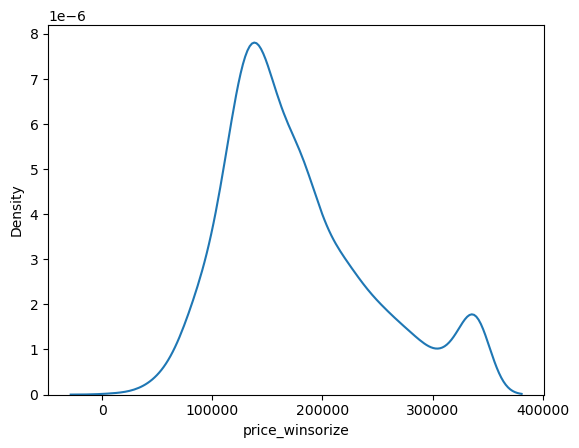

In [245]:
#7.6

ames['price_winsorize'] = ( (ames['price'] < lower_whisker) * lower_whisker 
+ (ames['price'] > upper_whisker) * upper_whisker 
+ (ames['price'] >= lower_whisker) * (ames['price'] <= upper_whisker) * ames['price'])

sns.kdeplot(ames['price_winsorize'])
ames['price_winsorize'].describe()

**Q7.6**

The table has now less wide, meaning that its range was reduced, particularly the right tail, where it now ends at the upper whisker value (339500). Because the winsorization essentially took the outliers and map it to the closest whisker value, there now is a jump in density between 300000 and 400000. The jump may have always been there, but probably has just been accentuated more since we were able to reduce the range down to the upperwhisker. The median shouldn't have been really affected, but it seems like the mean was lowered, which makes sense since we rounded down the highest prices to the upper whisker.